# Exercise 1: GW Parameter Estimation with HMC
This exercise focuses on Bayesian parameter estimation for compact binary coalescences using frequency-domain gravitational-wave data. The goal is to infer the source parameters:

- Chirp mass $M_c$
- Symmetric mass ratio $\eta$, 
- Spins of the two BHs $s_{1,z}$ and  $s_{2,z}$
- Luminosity Distance $d_L$
- Inclination $\iota$
- Phase $\phi_c$
- Coalescence time $t_c$

by comparing a parametric waveform model - specifically, the $\rm IMRPhenomD$ model - to observed detector data.
In particular, I will focus on the observed data of the first gravitational wave event observed, i.e. $\rm GW150914$, for which the same analysis has already been executed, in order to have a direct comparison with my results.

In [2]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
import numpy as np
from matplotlib import pyplot as plt
import corner
from gwpy.timeseries import TimeSeries
import bilby
import jax
import jax.numpy as jnp
from numpyro.infer import MCMC, NUTS
import numpyro
import numpyro.distributions as dist
import ripplegw
import h5py
import pandas as pd
from matplotlib.lines import Line2D

### 1. Data Preparation


To retrieve the data and the detector properties, I use the bilby package, optimized for GW data and inference. In particular, I reload the data generated with the data_preparation.ipynb file, since CINECA working nodes do not have Internet access and my laptop came out of the battle quite beaten up...

Once the time series for LIGO Handford and Livingston were retrieved, I used the bilby Interferometer class to perform a Fourier Transform of the data to go to the frequency domain. Additionally, I also computed the noise PSD.

In [3]:
logger = bilby.core.utils.logger
outdir = "outdir_folder"

label = "GW150914" 
jax.config.update("jax_enable_x64", True)

H1 = bilby.gw.detector.get_empty_interferometer("H1")
L1 = bilby.gw.detector.get_empty_interferometer("L1")

In [4]:
geocentric_time = 1126259462.4    # event GPS time at which first GW discovered
post_event = 2                     # time after event
pre_event = 2                      # time before event
duration = pre_event + post_event  # total time range containing event
analysis_begin = geocentric_time - pre_event  # GPS time at which to start analysis

ra = 2.19432
dec = -1.2232
psi = 0.532268

In [5]:
H1_data = TimeSeries.read("H1_data.gwf", channel="H1:Strain")
H1psd = TimeSeries.read("H1_psd.gwf", channel='H1:Strain')

L1_data = TimeSeries.read("L1_data.gwf", channel="L1:Strain")
L1psd = TimeSeries.read("L1_psd.gwf", channel='L1:Strain')

In [6]:
H1.set_strain_data_from_gwpy_timeseries(H1_data)
L1.set_strain_data_from_gwpy_timeseries(L1_data)

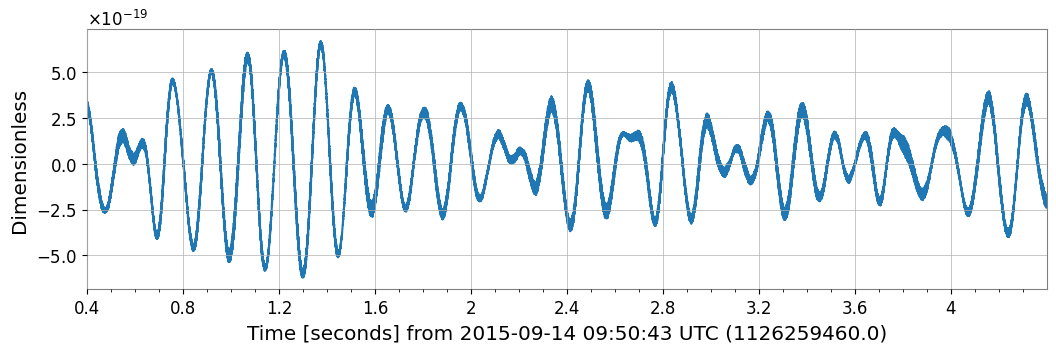

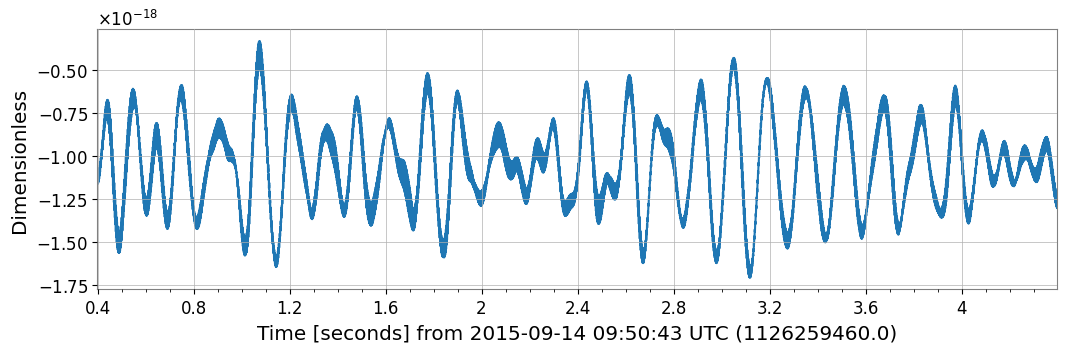

In [7]:
H1_data.plot()
plt.savefig("H1_data")
L1_data.plot()
plt.savefig("L1_data")

In [8]:
# duration typically multiplied by 32 for psd
psd_duration = duration * 32                
psd_begin = analysis_begin - psd_duration

# set interferometers with psd data
psd_alpha = 2 * H1.strain_data.roll_off / duration
H1psd_data = H1psd.psd(fftlength=duration, overlap=0, window=("tukey", psd_alpha), method="median")
H1.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(
    frequency_array=H1psd_data.frequencies.value, psd_array=H1psd_data.value)

psd_alpha = 2 * L1.strain_data.roll_off / duration
L1psd_data = L1psd.psd(fftlength=duration, overlap=0, window=("tukey", psd_alpha), method="median")
L1.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(
    frequency_array=L1psd_data.frequencies.value, psd_array=L1psd_data.value)

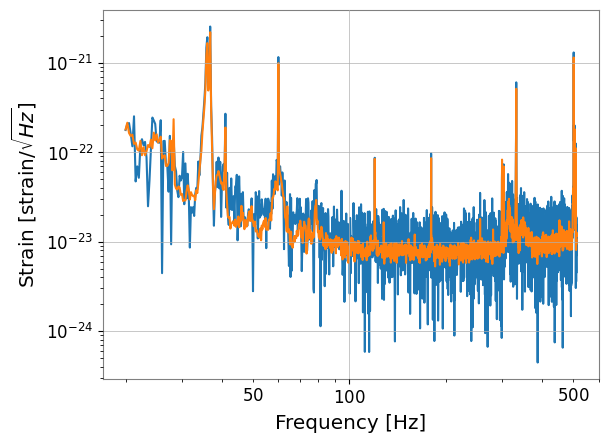

In [9]:
H1.minimum_frequency = 20.
H1.maximum_frequency = 512.
idxs = H1.strain_data.frequency_mask
a,b = list(H1.strain_data.frequency_array[idxs]),list(np.abs(H1.strain_data.frequency_domain_strain[idxs]))
c,d = list(H1.power_spectral_density.frequency_array[idxs]),list(H1.power_spectral_density.asd_array[idxs])

L1.maximum_frequency = 512
idxs = L1.strain_data.frequency_mask
L1a,L1b = list(L1.strain_data.frequency_array[idxs]),list(np.abs(L1.strain_data.frequency_domain_strain[idxs]))
L1c,L1d = list(L1.power_spectral_density.frequency_array[idxs]),list(L1.power_spectral_density.asd_array[idxs])
plt.plot(a,b)
plt.plot(c,d)
plt.yscale('log')
plt.xscale('log')
plt.xlabel("Frequency [Hz]")
plt.ylabel(r"Strain [strain/$\sqrt{Hz}$]")
plt.savefig("strainvfreq")

Once in the frequency domain, I prepared the data for the parameter estimation with Numpyro. In particular, I copied all the relevant informations - the frequency arrays, the strains in the frequency domain, the psd of each detector - in JAX arrays. Furthermore, I restricted my data in the relevant frequency range for the $\rm IMRPhenomD$ model, which is given by the $(\rm 20-512 Hz)$ range.

Additionally, from Bilby I also computed the antenna patterns associated with the two detectors during the observation of $\rm GW150914$. Since I assume the position of the source to be known, the values can be computed outside the sampler. If instead the position was part of the parameter estimation, these values would have to be computed with sampled values of RA, dec and $\psi$.

Finally, since I intend to use two detectors to infer the parameters associated with $\rm GW150914$, I also computed the time delay from the geocenter for each detector, to take into account the delay between the two detector observations in my waveform reconstruction.

In [10]:
f = jnp.array(H1.frequency_array)
fH1 = jnp.array(H1.frequency_array)
fL1 = jnp.array(L1.frequency_array)
maskH1 = (fH1 >= 20) & (fH1 <= 512)
maskL1 = (fL1 >= 20) & (fL1 <= 512)
f = f[maskH1]
fH1 = fH1[maskH1]
fL1 = fL1[maskL1]
df = f[1] - f[0]
dfH1 = f[1] - f[0]
dfL1 = f[1] - f[0]

dH1 = jnp.array(H1.strain_data.frequency_domain_strain[maskH1])
psdH1 = jnp.array(H1.power_spectral_density_array[maskH1])
FpH1 = jnp.float64(H1.antenna_response(ra, dec, geocentric_time, psi, 'plus'))
FcH1 = jnp.float64(H1.antenna_response(ra, dec, geocentric_time, psi, 'cross'))

dL1 = jnp.array(L1.strain_data.frequency_domain_strain[maskL1])
psdL1 = jnp.array(L1.power_spectral_density_array[maskL1])
FpL1 = jnp.float64(L1.antenna_response(ra, dec, geocentric_time, psi, 'plus'))
FcL1 = jnp.float64(L1.antenna_response(ra, dec, geocentric_time, psi, 'cross'))

tau_H1 = jnp.float64(H1.time_delay_from_geocenter(ra, dec, geocentric_time))
tau_L1 = jnp.float64(L1.time_delay_from_geocenter(ra, dec, geocentric_time))
t0_H1 = jnp.float64(H1.strain_data.start_time)
t0_L1 = jnp.float64(L1.strain_data.start_time)

tc_ref = jnp.float64(geocentric_time - t0_H1)

### 2. Likelihood and Waveform Reconstruction

Once all the data has been prepared, I define the Likelihood and the Waveform model to instruct the HMC sampler.
In particular, for the likelihood I assume the usual GW likelihood, given by the inner product of the residuals between the data and the reconstructed waveform:

\begin{equation*}
    \mathcal{L} = -0.5 <d-h|d-h>
\end{equation*}

where the inner product is given by:


\begin{equation*}
    <a|b> = 4 \rm Re \int{ \frac{\tilde{a}^*(f)\tilde{b}(f)}{S_n(f)}df      }
\end{equation*}

under the assumption of stationary Gaussian noise. 


Waveforms are generated using the RippleGW implementation of the $\rm IMRPhenomD$ model, which provides a fast and differentiable approximation suitable for gradient-based inference. Once the plus and cross polarization are computed through the $\rm IMRPhenomD$ model, the antenna pattern functions and the time delay with respect to the signal detection are taken into account to compute the final strain of the GW signal for each detector as follows:

\begin{equation*}
    \rm \tilde{h}_d(f) = \bigl(F_{p,d}h_p + F_{c,d}h_c\bigr)\exp\bigl[{-2i\pi f(t_{c,ref} + \tau_d)}\bigr]
\end{equation*}

where $\rm t_{c,ref}$ appears outside the plus and cross polarization because the $\rm IMRPhenomD$ model does not include it as a parameter.

As for the priors, for each parameters uniform priors are considered.

In [11]:
def _logL(data_f, model_f, psd):
    residual = data_f - model_f
    return -0.5 * 4.0 * jnp.sum(jnp.real(residual * jnp.conj(residual) / psd)) * df

waveform = ripplegw.IMRPhenomD(f_ref=20.0)
def gw_model(freqs, d_H1, d_L1, Sn_H1, Sn_L1):
    M_c = numpyro.sample("M_c", dist.Uniform(10.0, 40.0))
    eta = numpyro.sample("eta", dist.Uniform(0.1, 0.25))
    s1_z = numpyro.sample("s1_z", dist.Uniform(-0.99, 0.99))
    s2_z = numpyro.sample("s2_z", dist.Uniform(-0.99, 0.99))
    d_L = numpyro.sample("d_L", dist.Uniform(100.0, 1000.0))
    dt_c = numpyro.sample("dt_c", dist.Uniform(tc_ref - 0.1, tc_ref + 0.1))
    phase_c = numpyro.sample("phase_c",  dist.Uniform(0.0, 2*jnp.pi))
    cos_iota = numpyro.sample("cos_iota", dist.Uniform(-1.0, 1.0))
    iota = jnp.arccos(cos_iota)
    numpyro.deterministic("iota", iota)
    
    wf_params = dict(
        M_c = M_c,
        eta = eta,
        s1_z = s1_z,
        s2_z = s2_z,
        d_L = d_L,
        phase_c = phase_c,
        iota = iota,
    )
    
    pol = waveform(freqs, wf_params)
    hp, hc = pol["p"], pol["c"]
    
    tc_H1 = dt_c + tau_H1
    h_H1 = (FpH1*hp+FcH1*hc)*jnp.exp(-2j*jnp.pi*freqs*tc_H1)

    tc_L1 = dt_c+tau_L1
    h_L1 = (FpL1*hp+FcL1*hc)*jnp.exp(-2j*jnp.pi*freqs*tc_L1)

    df = freqs[1]-freqs[0]
    
    logL = _logL(d_H1, h_H1, Sn_H1)+_logL(d_L1, h_L1, Sn_L1)
    numpyro.factor("log_likelihood", logL)

Once the likelihood and the reconstructed waveform are defined, the HMC sampler is implemented, with a warmup of 2000 and a number of samples equal to 2000.

In [12]:
kernel = NUTS(gw_model)
mcmc = MCMC(kernel, num_warmup=2000, num_samples=2000, num_chains=1, progress_bar=True,)

rng_key = jax.random.PRNGKey(42)
mcmc.run(
    rng_key,
    freqs=fH1,
    d_H1=dH1,
    d_L1=dL1,
    Sn_H1=psdH1,
    Sn_L1=psdL1,
)

posterior = mcmc.get_samples()
mcmc.print_summary()

sample: 100%|██████████████████████████| 4000/4000 [45:59<00:00,  1.45it/s, 1023 steps of size 1.24e-03. acc. prob=0.95]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
       M_c     30.36      0.94     30.33     28.82     31.91    462.78      1.00
  cos_iota     -0.57      0.27     -0.56     -1.00     -0.21    100.25      1.00
       d_L    378.36    100.33    355.65    245.72    545.67     95.52      1.00
      dt_c      2.01      0.00      2.01      2.01      2.02    112.99      1.01
       eta      0.24      0.00      0.25      0.24      0.25    630.16      1.00
   phase_c      3.19      0.42      3.21      2.54      3.87    225.42      1.00
      s1_z      0.13      0.43      0.22     -0.61      0.81     98.46      1.01
      s2_z     -0.33      0.53     -0.43     -0.99      0.50     95.96      1.01

Number of divergences: 0


And the results are visualized through the following corner plot.

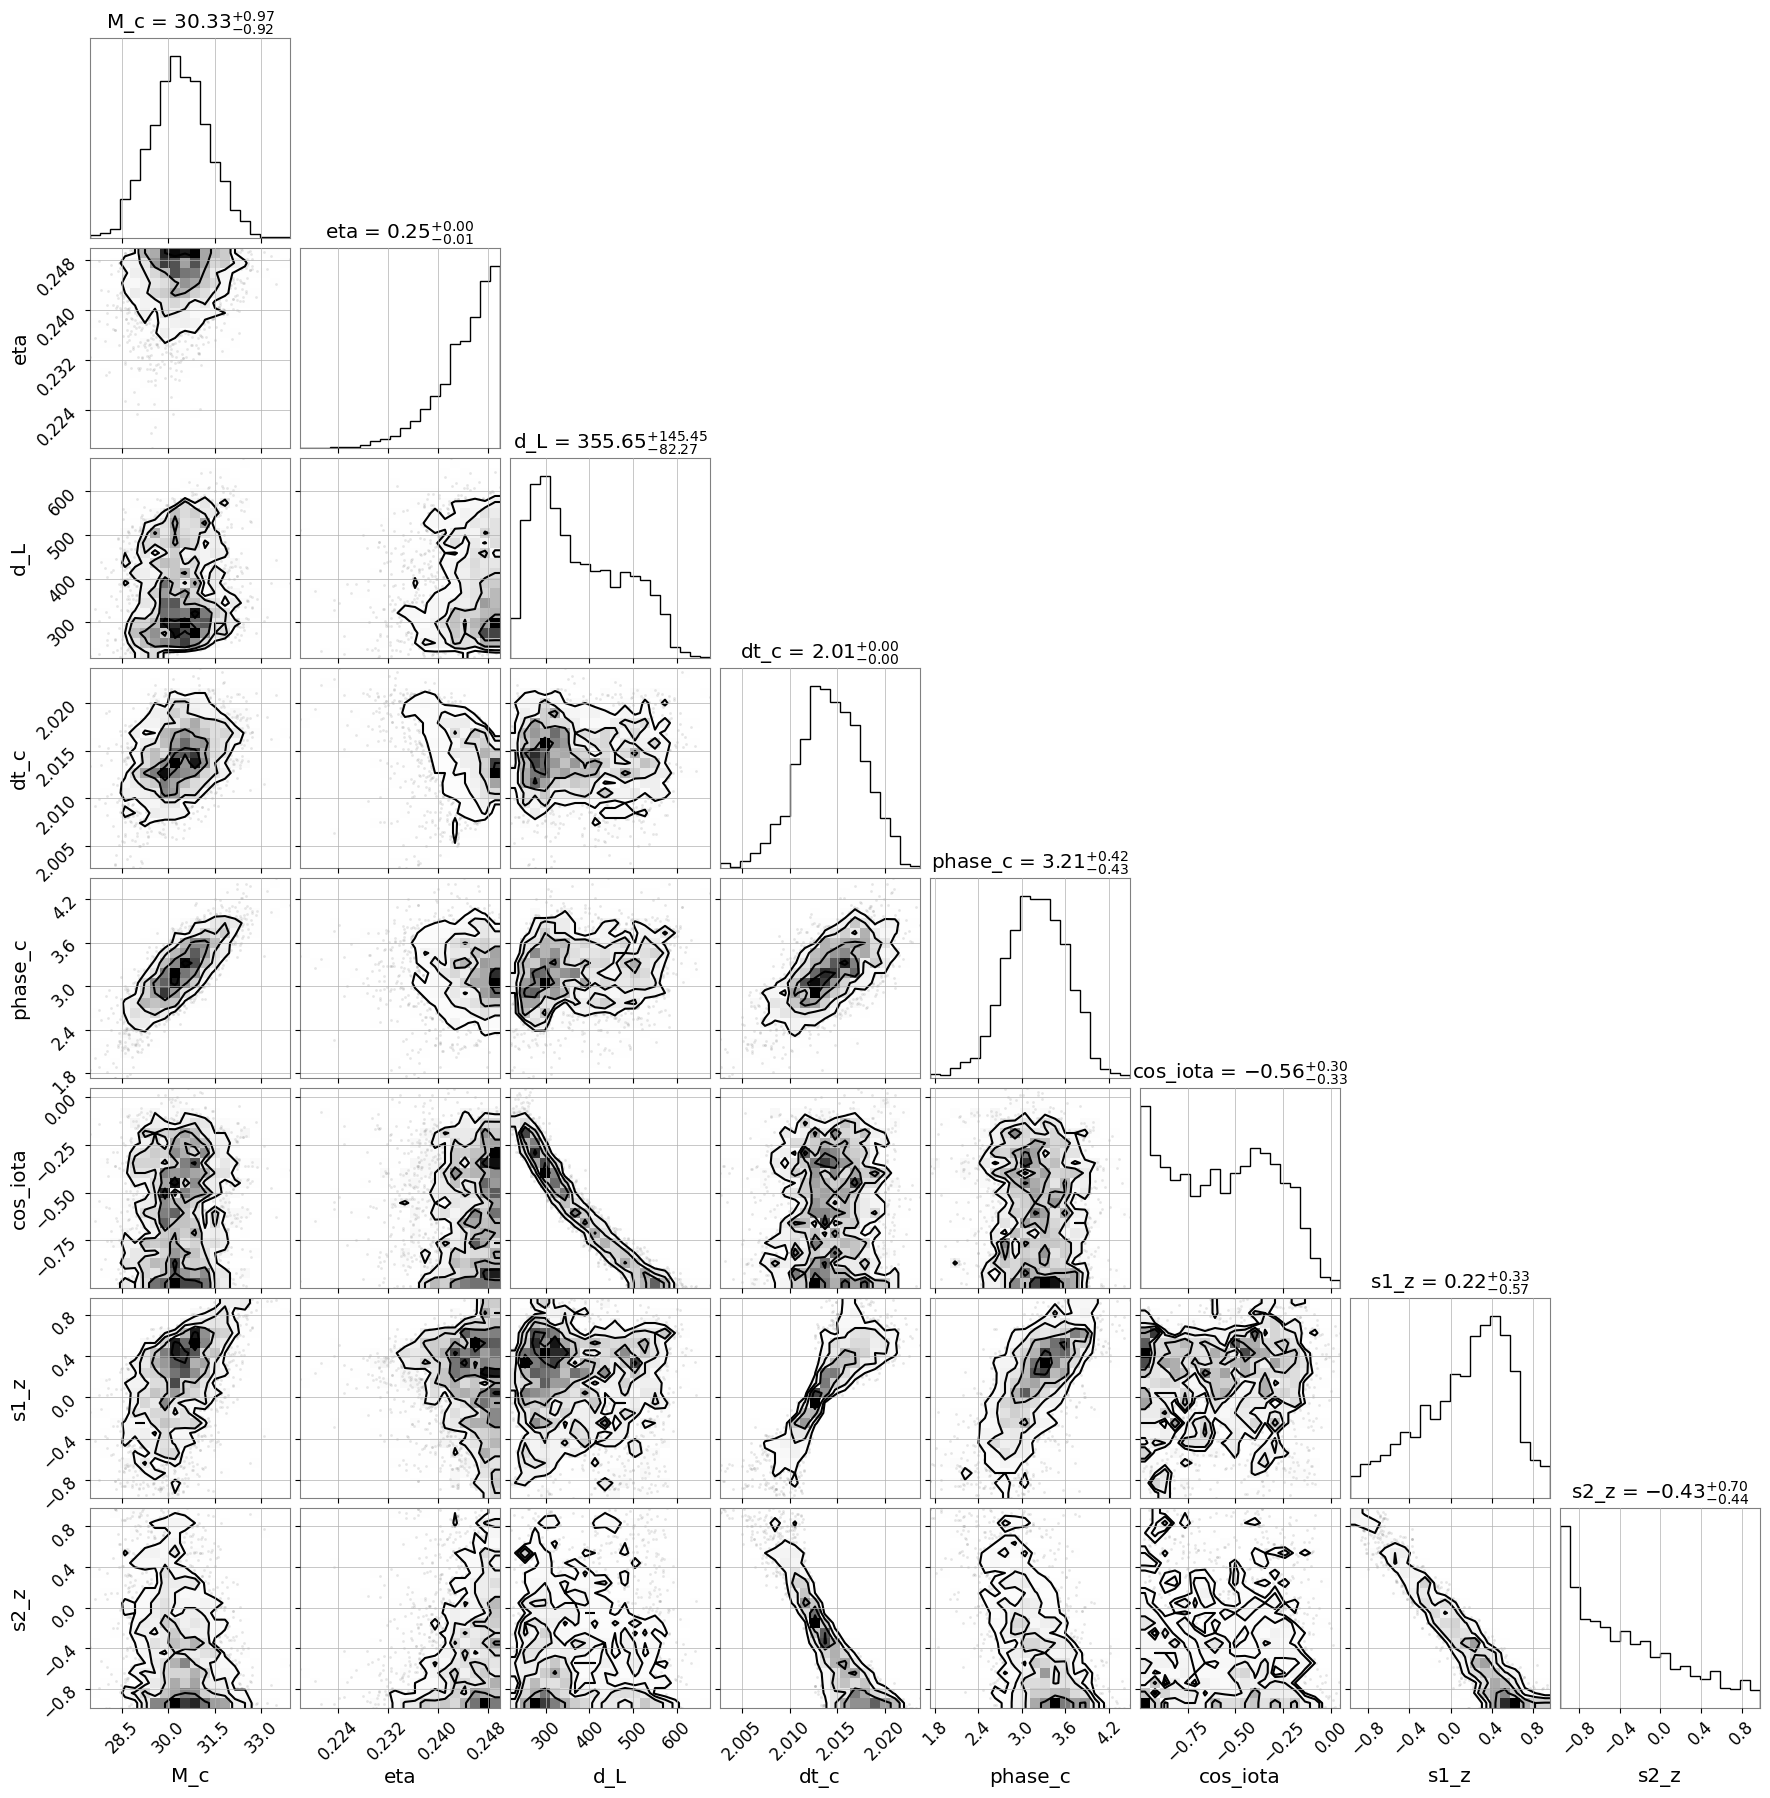

In [13]:
posterior = mcmc.get_samples()
keys   = ["M_c", "eta", "d_L", "dt_c", "phase_c", "cos_iota", "s1_z", "s2_z"]
samples_np = {k: np.array(v) for k, v in posterior.items()}

data_corner = np.vstack([samples_np[k] for k in keys]).T

fig = corner.corner(
    data_corner,
    labels=keys,
    show_titles=True,
    title_fmt=".2f",
)

### 3. Posterior Comparison

The results obtained from the NUTS sampler can be also compared to the posterior obtained by the LIGO collaboration provided by the GWOSC catalog. 
In particular, it is possible to compare the results obtained for the black hole masses and the luminosity distance of the binary, since the model used by the LIGO collaboration relied on different parameters with respect to the rippleGW $\mathrm{IMRPhenomD}$ model.

In [14]:
f = h5py.File('GW150914_GWTC-1.hdf5', 'r')

In [15]:
ligo_samples=pd.DataFrame.from_records(np.array(f['Overall_posterior']))
dropped = ['costheta_jn', 'right_ascension', 'declination', 'costilt1', 'costilt2', 'spin1', 'spin2']
ligo_samples = ligo_samples.drop(dropped, axis=1)
ligo_samples

,luminosity_distance_Mpc,m1_detector_frame_Msun,m2_detector_frame_Msun
0,517.176717,39.037380,37.044563
1,401.626864,34.620096,34.184416
2,369.579071,37.894343,33.970520
3,386.935268,36.412973,35.684463
4,345.104345,39.477251,31.645008
...,...,...,...
8345,306.985025,37.561962,33.355792
8346,462.649414,37.824298,36.674075
8347,448.930876,38.063291,35.757913
8348,561.020036,44.884396,31.592433


Since the GWOSC catalog returns the posterior for $\mathrm M_1$ and $\mathrm M_2$, before the comparison it is necessary to convert the $\mathrm{M_c}$ and $\eta$ samples given by the NUTS sampler.

In [16]:
def Mc_eta_to_m1_m2(M_c, eta):
    M = M_c/eta**(3.0/5.0)

    sqrt_term = np.sqrt(1.-4.*eta)

    m1 = 0.5*M*(1.+sqrt_term)
    m2 = 0.5*M* (1.-sqrt_term)

    return m1, m2    

In [17]:
samples_np = {k: np.array(v) for k, v in posterior.items()}
np.savez("nuts_samples_gw150914.npz", **samples_np)
samples_np['M_c'], samples_np['eta'] = Mc_eta_to_m1_m2(samples_np['M_c'], samples_np['eta'])
keys = ["d_L", "M_c", "eta"]
data_corner = np.vstack([samples_np[k] for k in keys]).T

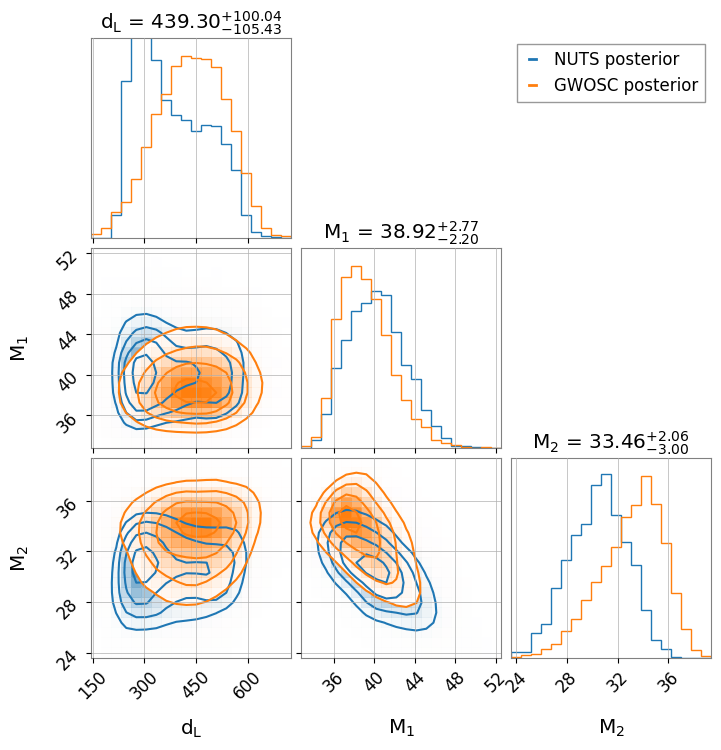

In [21]:
labels   = [r"$\mathrm{d_L}$", "$\mathrm{M_1}$", "$\mathrm{M_2}$"]
combined = np.vstack([data_corner, ligo_samples])

ranges = [
    (np.min(combined[:, i]), np.max(combined[:, i]))
    for i in range(combined.shape[1])
]

fig = corner.corner(
    data_corner,
    labels=labels,
    range=ranges,
    show_titles=False,
    color="C0",
    plot_datapoints=False,
    fill_contours=False,
    smooth=1.0,
    hist_kwargs={"density": True},
)

corner.corner(
    ligo_samples,
    fig=fig,
    labels=labels,
    range=ranges,
    show_titles=True,          
    title_fmt=".2f",
    color="C1",
    plot_datapoints=False,
    fill_contours=False,
    smooth=1.0,
    hist_kwargs={"density": True},
)

fig.legend(
    handles=[
        Line2D([0], [0], color="C0", lw=2, label="NUTS posterior"),
        Line2D([0], [0], color="C1", lw=2, label="GWOSC posterior"),
    ],
    loc="upper right",
    bbox_to_anchor=(0.95, 0.95),
)

plt.show()

As it can be seen from the corner plot, the results from the NUTS sampler are comparable with the ones provided by the LIGO collaboration for the set of parameters under exam.